# Week 3: First steps with matrices: applying matrices to vectors

A **matrix** is a table or list of vectors of the same dimension. The plural of matrix is **matrices**. There are many valuable ways to think about matrices. 
1. A matrix gives instructions for changing a vector into a new vector
1. The columns of a matrix are a list of vectors
1. The rows of a matrix are a list of vectors
1. A matrix is a table of data



Here is the plan for this lesson
1. Say what a matrix is and give some examples; shape; rows and columns
2. The *tranpose* exchanges rows and columns
3. Representing a matrix a list of rows or a list of columns
3. Matrices give instructions for changing vectors into other vectors
    1. How a matrix changes a vector into another vector: row view. The entries of $Mv$ are the dot products of the *rows* of $M$ with $v$.
    2. How a matrix changes a vector into another vector: column view. $Mv$ is a linear combination of the *columns* of $M$ with coefficients given by the *entries* of $v$.
3. Matrix action distribute over linear combinations
    1. A matrix $M$ send the line spanned by $v$ to the line spanned by $Mv$.
    2. A matrix $M$ sends the plane spanned by $v$ and $w$ to the plane spanned by $Mv$ and $Mw$.
    (I will demonstrate this in class. It can be hard to see in Python without practice)
4. Effect of diagonal matrices and rotation matrices in 2D

## Initialization Cells

In [1]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.widgets import Slider, Button

import math

# We need a random number generator

rng = np.random.default_rng()

In [2]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# This method draws arrows on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv,columns=False):
    #norm.autoscale(0,len(VectorList))
    VList = VectorList
    if columns: 
        VList = VectorList.T
        
    zeroes = np.zeros(len(VList))
    self.quiver(zeroes,
                zeroes,
                VList[:, 0],
                VList[:, 1],
                color=cmap(np.linspace(0, 1, len(VList),endpoint=False)),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector

def LADS3DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [TailAt[2]],[Vector[0]], [Vector[1]], [Vector[2]],
                color=col)

plt.Axes.LADS3DDrawVector = LADS3DDrawVector

# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])




### End of initialization cells

## Say what a matrix is and give some examples; shape; rows and columns

A **matrix** is a rectangular table of numbers. Here are three matrices $A$, $B$, and $C$.

In [3]:
A = np.array([[1,3],
             [2,2],
             [-1,0]])
B = np.array([[-1,1],
             [3,2]])
C = np.array([[2,0,1,-1.5,6.5],[0,3,3,10,-2],[-7,1,5,-8,-9]])
# REQUEST: Find out about how to present matrices in a prettier and more readable way.
print('A = \n', A)
print('\n B = \n', B)
print("\n C = \n", C)




A = 
 [[ 1  3]
 [ 2  2]
 [-1  0]]

 B = 
 [[-1  1]
 [ 3  2]]

 C = 
 [[ 2.   0.   1.  -1.5  6.5]
 [ 0.   3.   3.  10.  -2. ]
 [-7.   1.   5.  -8.  -9. ]]


$A$ has 3 **rows** and 2 **columns**, $B$ has two rows and two columns, and $C$ has three rows and five columns. In a matrix, all the columns are the same length, and all the rows are the same length. Python lets you find the shape of a matrix using the "shape" method:

In [4]:
print(A.shape)
print(B.shape)
print(C.shape)

(3, 2)
(2, 2)
(3, 5)


The shape method lists the number of rows first and then the number of columns. This is the convention in linear algebra: a $3 \times 2$ matrix or a $3$ by $2$ matrix means a matrix that has 3 *rows* and 2 *columns*. We'll also use the term "shape": the shape of $A$ is 3 by 2 or $3\times 2$.

If a matrix has the same number of rows and columns, it is called a **square** matrix. Above, $B$ is a square matrix.

Each row of the matrix is a vector. You can access the $j$ row of $A$ using the bracket notation $A[j]$. As usual with Python, the row numbering starts with $0$. 

In [5]:
# This is the zero row of A. 
print(A[0])

[1 3]


In [6]:
# This is the one row of A
print(A[1])

[2 2]


Each column of a matrix is a vector. You can access the columns of $A$ using Python's "slice" notation: $A[:,j]$ is the $j$ columnn of $A$. Again, the indexing starts with zero.

In [7]:
print("Reminder: this is A:")
print(A)

print("This is the zero column of A:",A[:,0])
print(A[:,0].shape)

Reminder: this is A:
[[ 1  3]
 [ 2  2]
 [-1  0]]
This is the zero column of A: [ 1  2 -1]
(3,)


Notice in the output cell above that when Python extracts the zero column, it prints it horizontally. It is just a numpy array of shape (3,).

In [8]:
#Let's see the same thing for the 1 column. 
print(A[:,1])
print(A[:,1].shape)


[3 2 0]
(3,)


You can access the entry in $i$ row and the $j$ column of a matrix using bracket notation too:

In [9]:
# as a demonstration we'll print the entry in the 2 row and 0 column of A, and the 1 row and 1 column of B.
# First, this is only easy to check if we remember what A and B are.
print(A)
print(B)
print(A[2,0])
print(B[1,1])

[[ 1  3]
 [ 2  2]
 [-1  0]]
[[-1  1]
 [ 3  2]]
-1
2


In [10]:
#Now let's remember the matrix C
print(C)

[[ 2.   0.   1.  -1.5  6.5]
 [ 0.   3.   3.  10.  -2. ]
 [-7.   1.   5.  -8.  -9. ]]


## 2. The *transpose* exchanges rows and columns

Here is a $2 \times 5$ matrix $M$. Remember that means that $M$ has $2$ rows and $5$ columns.

In [11]:
M = np.array([[1,3,5,9,11],[0,-2,-4,-6,-8]])
print(M)
M.shape

[[ 1  3  5  9 11]
 [ 0 -2 -4 -6 -8]]


(2, 5)

The "tranpoose" of $M$, usually written $M^T$, exchanges the rows and columns of $M$: so $M^T$ is a 2-row by 5-column matrix.

In [12]:
print(np.transpose(M))
np.transpose(M).shape

[[ 1  0]
 [ 3 -2]
 [ 5 -4]
 [ 9 -6]
 [11 -8]]


(5, 2)

Numpy gives several ways to transpose $M$; they're all equally good. Use the one that's most convenient for you. Here are two others: these are methods of the numpy array class. 

In [13]:
print(M.transpose())
print(M.T)

[[ 1  0]
 [ 3 -2]
 [ 5 -4]
 [ 9 -6]
 [11 -8]]
[[ 1  0]
 [ 3 -2]
 [ 5 -4]
 [ 9 -6]
 [11 -8]]


So far we've built our matrices by listing their rows. Often we want to build a matrix by specifying its *columns*. The tranpose makes it easy to do that. 

Let's build a matrix $A$ with rows $[1,3,5]$ and $[2,4,6].$ Then let's build a matrix $B$ with columns $[10,9,8]$ and $[5,4,3]$.

In [14]:
A = np.array([[1,3,5],[2,4,6]])
print ("We built A in one step. A = ")
print(A)
print("For B, first we build a matrix with rows [10,9,8] and [5,4,3]." )
C = np.array([[10,9,8],[5,4,3]])
print(C)
print("Then we take its tranpose.")      
B = C.T
print ("B = ")
print(B)

# We can also build B in one line.

D = np.array([[10,9,8],[5,4,3]]).T

print(B == D)

We built A in one step. A = 
[[1 3 5]
 [2 4 6]]
For B, first we build a matrix with rows [10,9,8] and [5,4,3].
[[10  9  8]
 [ 5  4  3]]
Then we take its tranpose.
B = 
[[10  5]
 [ 9  4]
 [ 8  3]]
[[ True  True]
 [ True  True]
 [ True  True]]


#### **Do it:** Make a matrix with columns $[1,2,3], [3.14, 7, 11], [5,2,14]$.

In [15]:
# Enter the code here
X = np.array([[1, 3.14, 5], [2, 7, 2], [3, 11, 14]])
print(X)

[[ 1.    3.14  5.  ]
 [ 2.    7.    2.  ]
 [ 3.   11.   14.  ]]


## Representing a matrix as a list of rows or a list of columns

Suppose that $M$ is an $n\times k$ matrix: remember this means that $M$ has $n$ rows and $k$ columns. We'll often want to represent $M$ as a list of rows or a list of columns. The notation 

$$
M = \begin{bmatrix} \text{---} & r_0 & \text{---} \\
                   \text{---} & r_1 & \text{---} \\
                   & \vdots & \\
                   \text{---} & r_{n-1}& \text{---}
                   \end{bmatrix}
$$

will mean that $r_0, \ldots, r_{n-1}$ are each $k$-vectors that are the rows of $M$. The notation 

$$
M = \begin{bmatrix} | & & | \\
                    c_0 & \ldots & c_{k-1}  \\
                    | & & | 
                    \end{bmatrix}
$$

will mean that $c_0,\ldots, c_{k-1}$ are each $n$-vectors that are the columns of $M$.

**Discussion topic:** 
>If $M$ is a matrix, then the number of *columns* of $M$ is the length of each *row*. The number of *rows* of $M$ is the length of each *column*.

So if $M$ is an $n\times k$ matrix, then $M$ has $n$ rows of length $k$. We can say that $k$ is the **number of columns** or  the **row length** of $M$.

If $M$ is an $n\times k$ matrix, then $M$ has $k$ columns of length $n$. We can say that $n$ is the **number of rows** or the **column length** of $M$.

## Matrices are instructions for changing vectors into other vectors

A matrix with $n$ rows and $k$ columns gives instructions for changing or "transforming" a $k$-dimensional vector  into an $n$-dimensional vector. This is a very important way to view a matrix, and we'll study it from many points of view. It's so important that Python has a special notation for applying a matrix $A$ to a vector $v$: the ampersand $@$ as in $A@v$. This is the same symbol that Python uses for the dot product. We'll soon see why.

In [16]:
# Here is a 3 times 2 matrix A. We'll use it to turn a 2D vector into a 3D vector.
A = np.array([[1,2],
              [3,4],
              [5,6]])
print(A)
A.shape

[[1 2]
 [3 4]
 [5 6]]


(3, 2)

In [17]:
# Here is a 2D-vector v
v = np.array([-1,3])
print(v)
v.shape

[-1  3]


(2,)

In [18]:
# We apply A to v. The output is a 3D-vector, becase A has 3 rows.
print(A@v)
(A@v).shape

[ 5  9 13]


(3,)

### Applying a matrix to a vector: the row view

Suppose $A$ is an $n\times k$ matrix, with rows $r_0,\ldots,r_{n-1}$:
$$
A = \begin{bmatrix} \text{---} & r_0 & \text{---} \\
                   \text{---} & r_1 & \text{---} \\
                   & \vdots & \\
                   \text{---} & r_{n-1}& \text{---}
                   \end{bmatrix}.
$$
We can apply it to $k$-vector and get an $n$-vector. If $v$ is a $k$-vector, then $Av$ is the $n$-vector with entries
$$
Av = [r_0 \cdot v, r_1 \cdot v, \ldots, r_{n-1} \cdot v].
$$

> The $j$ entry of Av is the dot product of the $j$ row of $A$ with $v$.

This helps explain why you apply an $n\times k$ matrix to a $k$-vector: $k$ is the length of each row, and you dot each row with $v$ to get $Av$.  The length of the rows and the length of $v$ have to be the same so that you can use the dot product. 

It also explains why $Av$ is an $n$-vector: $n$ is the number of rows, and you dot each row with $v$ to compute $Av$: that means $Av$ has $n$ entries.

Often when people apply matrices to vectors, they write the input vector and the output vectors as single columns: using that convention the formula for $Av$ is
$$
Av = \begin{bmatrix} r_0\cdot v \\
\vdots \\
r_{n-1}\cdot v
\end{bmatrix}.
$$

The columnn notation for vectors is great for understanding matrix multiplication. Python doesn't use it because making columns isn't a convenient way to enter code. We'll use it when writing prose: column notation is very common in writing aboult linear algebra, and it helps for understanding applying matrices to vectors and multiplying matrices. It's good to become familiar with it.


In [19]:
# Now let's try the row dot product view of applying matrices to vectors in Python.

# Here is a 2 by 2 matrix A
A = np.array([[1,3],
               [-5,7]])
print("Here is A.")
print(A)

Here is A.
[[ 1  3]
 [-5  7]]


In [20]:
# Here is a 2D vector v
#
v = np.array([-2,4])
print("Here is v.")
print(v)

Here is v.
[-2  4]


In [21]:
# Let's check that applying A to v using @ is the same as computing the dot product of each row of A with v.
print ("First let's compute Av")
print ("Av is ",A@v)

First let's compute Av
Av is  [10 38]


In [22]:
print ("Now let's get the rows of A")
print ("The zero row is ",A[0])
print ("The one row is ", A[1])

Now let's get the rows of A
The zero row is  [1 3]
The one row is  [-5  7]


In [23]:
print ("Taking the dot product of each row of A with v.")
print("The dot product of the zero row of A with v is ", A[0]@v)
print("The dot product of the 1 row of A with v is ", A[1]@ v)

Taking the dot product of each row of A with v.
The dot product of the zero row of A with v is  10
The dot product of the 1 row of A with v is  38


In [24]:
# Let's also use python that we got the same thing from applying A to v and by dotting each row with v. 
print(A @ v == np.array([A[0]@v, A[1]@v]))

[ True  True]


In [25]:
# You can put your work in some code cells here.
M = np.array([[2, 4, 5], [1, 6, 4]])
x = np.array([5, 3, 2])
print("Mx = ", M@x)
print("M[0]x = ", M[0]@x)
print("M[1]x = ", M[1]@x)
print(M@x == np.array([M[0]@x, M[1]@x]))

Mx =  [32 31]
M[0]x =  32
M[1]x =  31
[ True  True]


### Applying a matrix to a vector: the column view

The "column view" of matrix mulitplication is even more important than the row view. If $A$ is an $n\times k$ matrix whose $k$ columns are 
$$
A = \begin{bmatrix} | & & | \\
                    c_0 & \ldots & c_{k-1}  \\
                    | & & | 
                    \end{bmatrix},
$$
and $v$ is the length $k$ vector $v = [v_0,...,v_{k-1}],$ then
$$
A v = v_0 c_0 + v_1 c_1 + ... + v_{k-1} c_{k-1}.
$$
If we write $v$ as a column vector then this is
$$
\begin{bmatrix} | & & | \\
                    c_0 & \ldots & c_{k-1}  \\
                    | & & | 
                    \end{bmatrix} \begin{bmatrix} v_0 \\ \vdots \\ v_{k-1} \end{bmatrix} = v_0 c_0 + v_1 c_1 + ... + v_{k-1} c_{k-1}.
$$
>If $A$ is an $n\times k$ matrix and $v$ is a $k$-vector, then $Av$ is the linear combination of the columns of $A$ with coefficients given by the entries of $v$.

The column view shows you why the output of $Av$ has length $n$: each column $c_i$ has $n$ entries. It also explains why the input is a $k$-vector: $A$ has $k$ columns, and you need a coefficient for each column in the linear combination.

In [26]:
# Here is our 2 by 2 matrix A again. 

A = np.array([[1,3],
               [-5,7]])
print(A)

[[ 1  3]
 [-5  7]]


In [27]:
# Here our 2D vector v
v = np.array([-2,4])
print(v)

[-2  4]


In [28]:
# Let's check that applying A to v is the same as 
# taking a linear combination of columns of A with coefficients given by the entries of v 
print ("First let's compute Av")
print ("Av is ",A@v)

First let's compute Av
Av is  [10 38]


In [29]:
print ("Now let's get the columns of A")
print ("The zero column of A is ",A[:,0])
print ("The one column is ", A[:,1])

Now let's get the columns of A
The zero column of A is  [ 1 -5]
The one column is  [3 7]


In [30]:
print("Now let's use the entries of v to make a linear combination of the columns of A")
print(v[0]* A[:,0] + v[1] * A[:,1])

Now let's use the entries of v to make a linear combination of the columns of A
[10 38]


In [31]:
print("We can also use Python to compare our two answers")
A @ v == v[0] * A[:,0] + v[1] * A[:,1]

We can also use Python to compare our two answers


array([ True,  True])

#### **Do it:** 
Make up an $n$ row by $k$ column matrix $M$ (2 by 2 is fine, but you can choose another shape) and a $k$D vector $x$. It is fine to use the $M$ and $x$ that you used in the last do-it. Compute $Mx$ in Python. If $M[:,0],...,M[:,k-1]$ are the columns of $M$ and $x[0],...,x[k-1]$ are the entries of $x$, compute the linear combination of the columns of $M$ given by the entries of $x$:
$$
    x[0] * M[:0] + ... + x[k-1] * M[:k-1].
$$
Check that $Mx$ equals this linear combination.

In [40]:
## You can put your work in code cells here.
M = np.array([[2, 4, 5], [1, 6, 4]])
x = np.array([5, 3, 2])
print("Mx = ", M@x)
print(x[0]*M[:,0] + x[1]*M[:,1]+ x[2]*M[:,2])

Mx =  [32 31]
[32 31]


## Matrix action distributes over linear combinations, so it preserves spans and sends lines to lines and planes to planes

If $v$ and $w$ are $kD$ vectors, $a$ and $b$ are scalars, and $M$ is an $n$ by $k$ matrix, then 
$$
   M(av + bw) = a Mv + b Mw.
$$
Let's check this in Python.

In [41]:
# Create v and w to be two random 2D-vectors with entries between -3 and 3.
# rng stands for "random number generator". We initialized it in the initialization cells.
# "uniform" means uniformly distributed random numbers.


v = rng.uniform(-3.,3.,size=(2))
print(v)
w = rng.uniform(-3.,3.,size=(2))
print(w)



[-2.14069468 -2.27131876]
[-2.83218584 -1.77005415]


In [42]:
# Create two random scalars a and b between -5 and 5
a = rng.uniform(-5.,5.)
b = rng.uniform(-5.,5.)
print(a)
print(b)

-0.8075259969338742
-4.06288174934287


In [43]:
# M is a random 3 by 2 matrix with entries betwee -5 and 5.
M = rng.uniform(-5.,5.,size=(3,2))
print(M)

[[ 2.26902874  3.98766367]
 [ 3.15163908 -0.7347536 ]
 [-0.17087386  1.81651072]]


In [44]:
print("Here is M(av + bw):")
x = M@ (a*v + b*w)
print(x)

print("Here is a Mv + b Mw:")
y = a * M@v + b* M@w
print(y)

print("Are they equal? Let's print their difference.")

print(x-y)

print("Close enough.")

# There is also a python function "allclose" that returns True if all the entries of a vector 
# or matrix are close to each other

print(np.allclose(x,y))

Here is M(av + bw):
[66.02307106 35.08188435 14.13362414]
Here is a Mv + b Mw:
[66.02307106 35.08188435 14.13362414]
Are they equal? Let's print their difference.
[0.00000000e+00 7.10542736e-15 1.77635684e-15]
Close enough.
True


Let $s$ be a natural number, and let $v_0, ..., v_{s-1}$ be $s$ $kD$ vectors. Let $a_0,...,a_{s-1}$ be $s$ scalars. The fact that
$$
M(av+ bw) = a Mv + bMw
$$
means that 

> $M$ distributes over linear combinatons:
$$
 M(a_0 v_0 + ... + a_{s-1} v_{s-1}) = a_0 Mv_0 + ... + a_{s-1} Mv_{s-1}.
$$
In other words, if a vector $z$ is in the span of $v_0,...,v_{s-1}$, then $Mz$ is in the span of $Mv_0,...,Mv_{s-1}.$

Geometrically, this means that 

>matrices send lines through $0$ to lines through $0$ and planes through $0$ to planes through $0$. 

Let's see some examples.

### Matrix action preserves lines through the origin.

(2, 100)


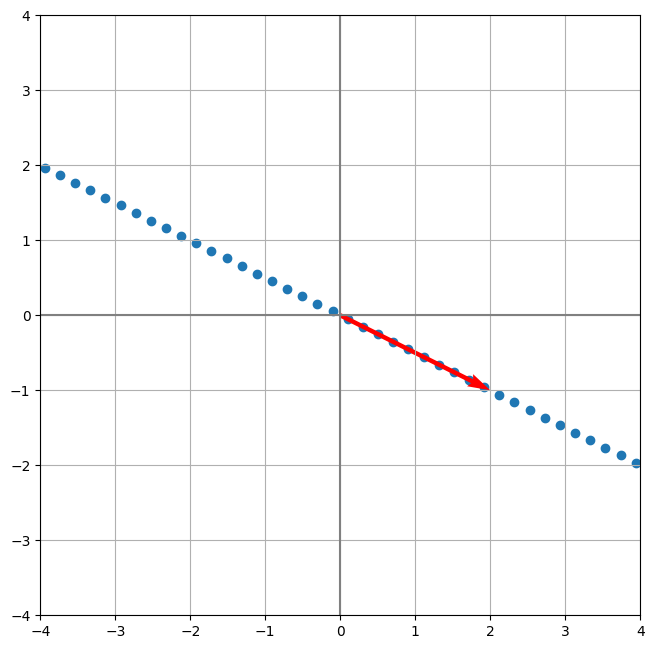

In [45]:
# Here is a 2D vectors v 
v = np.array([2,-1])

# Let's plot v and the linen generated by v, which is the same as the span of v or the scalar multiples of v.

fig,ax = LADS2DSquare(xlow=-4.,xhigh=4.)


# Draw the line generated by v. To do this we'll just take a bunch of scalar multiples of v
# The scalar multiples vary between -5 and 5

t = np.linspace(-5,5,100)

# span is an list of 100 multiples of v. Each column is a multiple of v, and there are 100 columns
# The 0 row is the x coordinates of the multiples, and the 1 row is the y coordinates

span = np.array([t*v[0],t*v[1]])
print(span.shape)

# We'll draw the line, but do it as a bunch of points to emphasize that each point is a vector
# that we can apply the matrix to.

ax.scatter(span[0],span[1])

# Also draw v. We draw it second so you can see it more easily.
ax.LADS2DDrawVector(v,col='r')



Here is M:
[[ 2  4]
 [-1  3]]


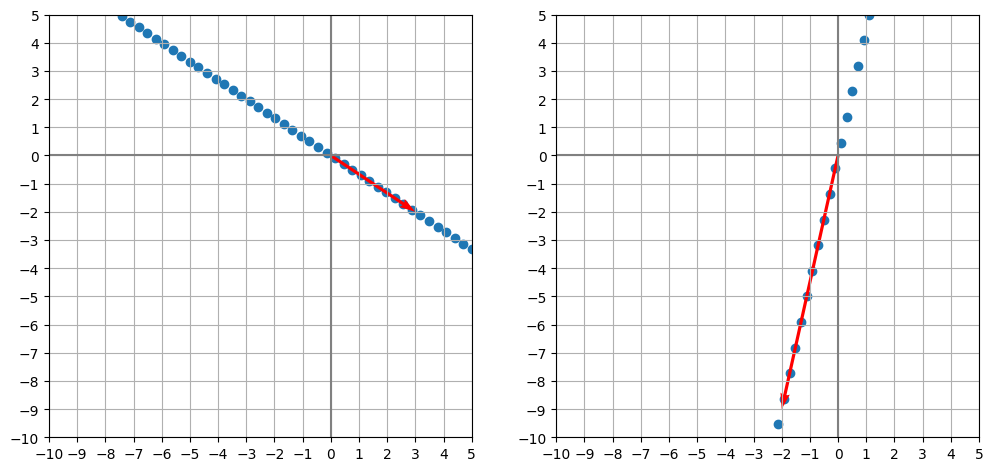

In [55]:
# Now here is a random 2 by 2 matrix.

v = np.array([3,-2])
t = np.linspace(-5,5,100)
# The 0 row is the x coordinates of the multiples, and the 1 row is the y coordinates
span = np.array([t*v[0],t*v[1]])

M = np.array([[2,4], [-1, 3]])
print("Here is M:")
print(M)

# Let's apply M to v and to the line generated by v

Mv = M @ v
Mspan = M @ span

# Now let's draw both


fig,ax = LADS2DSquare(2,xlow=-10.,xhigh=5.)

# Draw v and its span

ax[0].scatter(span[0],span[1])
ax[0].LADS2DDrawVector(v,col='r')


# On the next axis, draw M@v and M @ the span of v

ax[1].scatter(Mspan[0],Mspan[1])
ax[1].LADS2DDrawVector(Mv,col='r')


#### **Do it:** 
Try this yourself: make a 2D vector or two and a 2 by 2 matrix M. Make a scatter plot fo the line generated by your vector or vectors. Apply M to the vectors and to the line, and plot. Check that M sends the line generated by v to the line generated by Mv.

## Diagonal and rotation matrices in 2D

The first few code cells set up a list of 8 vectors arranged in a circle.

In [5]:
# t is an array of nwedges angles from 0 to 2pi, dividing the circle into nwedge equal wedges

nwedges = 8
t = np.linspace(0.,1.,nwedges,endpoint=False) * 2.0 * np.pi  
print ("nwedges angles in radians: ",t)

nwedges angles in radians:  [0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714]


In [6]:
# Here matrix with two rows and  nwedges columns. 
# Each column is a 2D unit vectors, pointing in the nwedges directions given by the angles t
# If t is an angle in radians, then (cos(t),sin(t)) is the corresponding point on the unit circle

List_of_Arrows_on_Circle = np.array([np.cos(t),np.sin(t)])
print(List_of_Arrows_on_Circle.shape)

(2, 8)


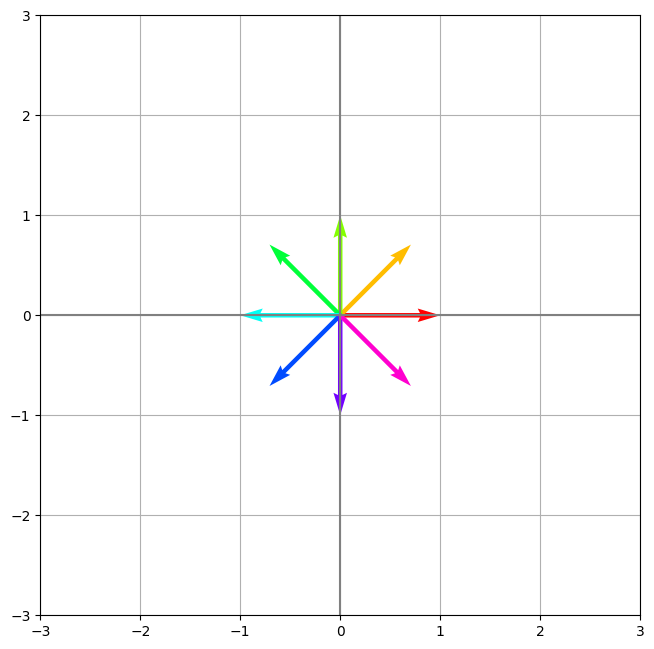

In [7]:
# Now let's draw those nwedges vectors as arrows so you can see what I mean.

fig,ax = LADS2DSquare(xlow=-3.0,xhigh=3.0)
ax.LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)

Now let's add a circle connecting all the points of the arrows

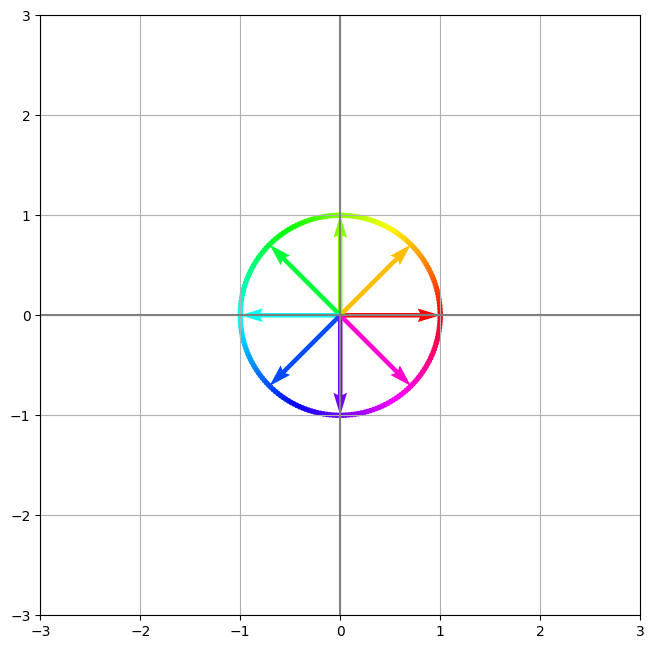

In [8]:
# Now let's add a circle connecting all the points of the arrows

# Create an array from 0 to 2pi with 200 points
theta = np.linspace(0, 2*np.pi, 200)

# UnitCirclePoints a matrix with 2 rows and 200 columns 
# Each column is a point on the unit circle.

UnitCirclePoints = np.array([np.cos(theta), np.sin(theta)])

# I want to color the cirlce when we draw it. colors is a list of values between 0 and 1, so it works as input
# to a matplotlib color map

colors  = theta/(2*np.pi)

# the scatter method draws a scatter plot. You send it a list of x-values and a list of y-values, and it
# draws a blob at each (x,y) point on the list.

# the colormap hsv has the same color at 1 as it does at zero, so the colors match up when the circle closes

ax.scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)
fig

### Diagonal matrices

Here is a matrix $M.$ 
It is called a "diagonal matrix" because its non-zero entries are on the diagonal line from the upper left to the lower right.

In [3]:
M = np.diag([0.5,2.])
print(M)

[[0.5 0. ]
 [0.  2. ]]


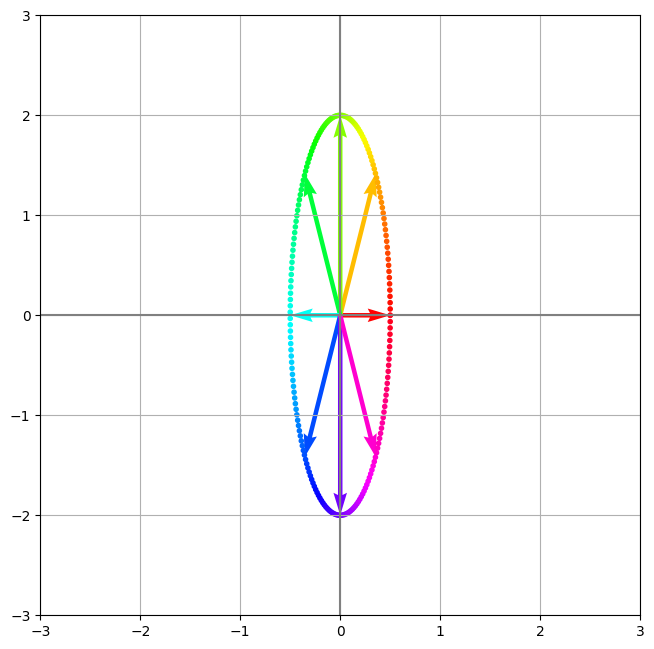

In [9]:
# Now let's apply it to our vectors on the unit circle.

newfig, newax = LADS2DSquare(xlow=-3.,xhigh=3.)

TransformedArrows = M @ List_of_Arrows_on_Circle
TransformedCircle = M @ UnitCirclePoints

newax.LADS2DDrawVectorList(TransformedArrows,columns=True)
newax.scatter(*TransformedCircle,marker=".",c=colors,cmap=cm.hsv)

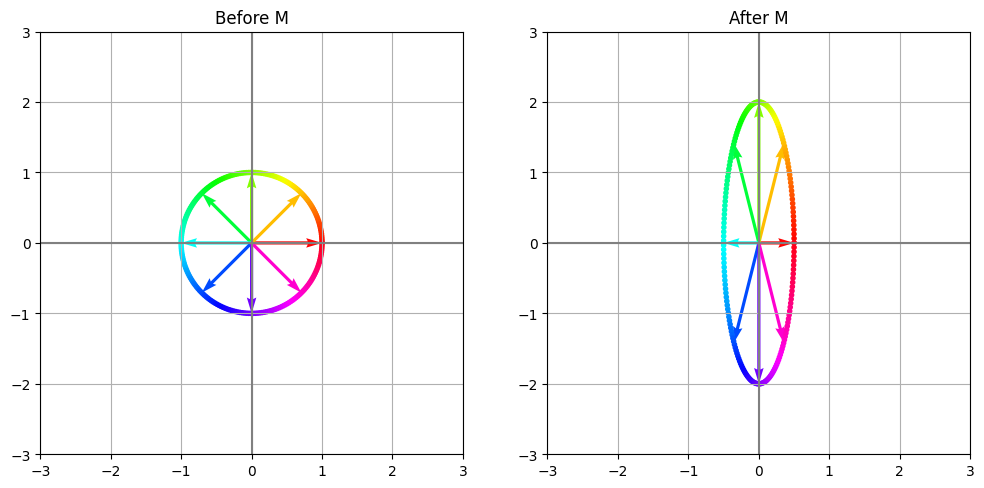

In [10]:
# Now show before and after at the same time 
M = np.diag([0.5,2.])

fig,ax = LADS2DSquare(2,xlow=-3.,xhigh=3.)

# By calling "LADS2DSquare" with the argument 2, we create an array of two axes, ax[0] and ax[1]. 
# We put the "before" picture on ax[0] and the "after" picture on ax[1].

ax[0].set_title('Before M')
ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

TransformedArrows = M @ List_of_Arrows_on_Circle
TransformedCircle = M @ UnitCirclePoints

ax[1].set_title('After M')
ax[1].LADS2DDrawVectorList(TransformedArrows,columns=True)
ax[1].scatter(*TransformedCircle,marker=".",c=colors,cmap=cm.hsv)




#### **Do it:**

Describe the effect of the matrix $M = \begin{bmatrix} 0.5 & 0 \\ 0 & 2 \end{bmatrix}$ on the vectors of the unit circle.

The effect of M is that the circle is squished by a factor of 2 (/2) and stretched by a factor of two (*2)

#### **Do it:** 

Copy the code cell above and modify it to try the same thing with the diagonal matrix $\begin{bmatrix} 2 & 0 \\ 0 & 3\end{bmatrix}$. Apply the matrix to the arrows and the points on the unit circle. 



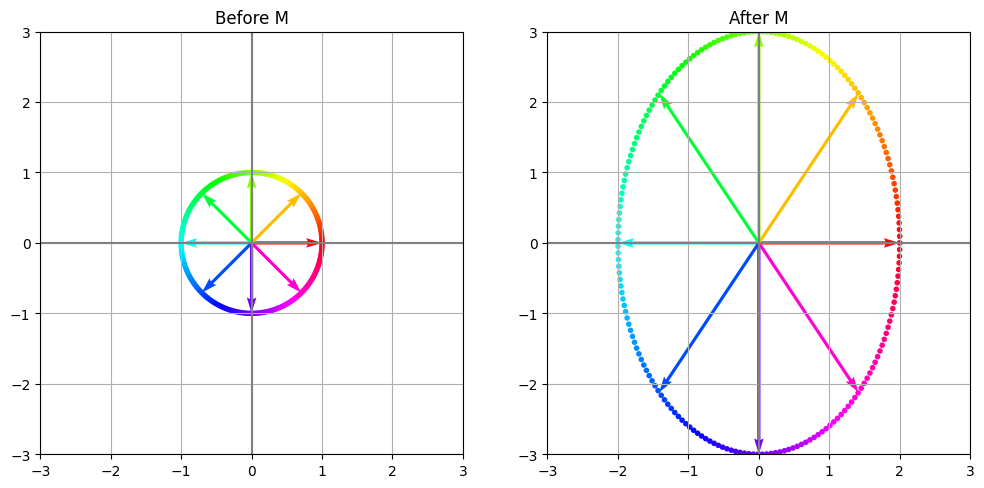

In [11]:
# Now show before and after at the same time 
M = np.diag([2,3])

fig,ax = LADS2DSquare(2,xlow=-3.,xhigh=3.)

# By calling "LADS2DSquare" with the argument 2, we create an array of two axes, ax[0] and ax[1]. 
# We put the "before" picture on ax[0] and the "after" picture on ax[1].

ax[0].set_title('Before M')
ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

TransformedArrows = M @ List_of_Arrows_on_Circle
TransformedCircle = M @ UnitCirclePoints

ax[1].set_title('After M')
ax[1].LADS2DDrawVectorList(TransformedArrows,columns=True)
ax[1].scatter(*TransformedCircle,marker=".",c=colors,cmap=cm.hsv)

### Rotation Matrices

If $\theta$ is an angle in radians, then the matrix
$$
R = \begin{bmatrix} \cos(\theta) & - \sin(\theta) \\
\sin(\theta) & \cos(\theta) \end{bmatrix}
$$
gives rotation counterclockwise by the angle $\theta$. (Rotation clockwise by $\theta$ is rotation counterclockwise by $-\theta$.

In [12]:
# For example, pi/4 is 45 degrees, so this matrix gives rotation by 45 degrees counterclockwise

R = RotationMatrix2D(np.pi/4)

To see what we mean by "gives rotation", let's apply $R$ to the unit circle of arrows.

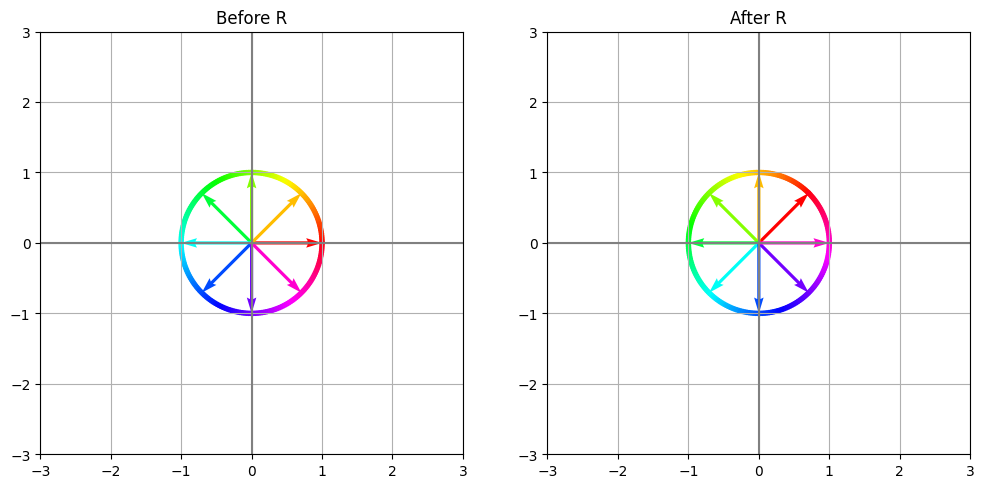

In [13]:
# Show the unit circle of arrows and R applied to it, next to each other. 

fig,ax = LADS2DSquare(2,xlow=-3.,xhigh=3.)

# By calling "LADS2DSquare" with the argument 2, we create an array of two axes, ax[0] and ax[1]. 
# We put the "before" picture on ax[0] and the "after" picture on ax[1].

ax[0].set_title('Before R')
ax[0].LADS2DDrawVectorList(List_of_Arrows_on_Circle,columns=True)
ax[0].scatter(*UnitCirclePoints,marker=".",c=colors,cmap=cm.hsv)

TransformedArrows = R @ List_of_Arrows_on_Circle
TransformedCircle = R @ UnitCirclePoints

ax[1].set_title('After R')
ax[1].LADS2DDrawVectorList(TransformedArrows,columns=True)
ax[1].scatter(*TransformedCircle,marker=".",c=colors,cmap=cm.hsv)





Above it can be hard to see what happened because *rotation doesn't change the length of a vector!* On the right you still have 8 vectors of length 1. But look closely at the colors. The red arrow is on the x axis on the left, and on the right it's been rotated to the 45 degree position. If you follow along, you'll see that each colored arrow has been rorated counterclockwise by 45 degrees or $\pi/4$ radians.

To make the rotation easier to see, and to see also what rotation does for vectors of other lengths, let's first stretch the unit circle into an ellipse. This time we'll rotate by $-\pi/6$. $\pi/6$ is 30 degrees, and the negative number corresponds to rotation *clockwise* instead of counterclockwise.

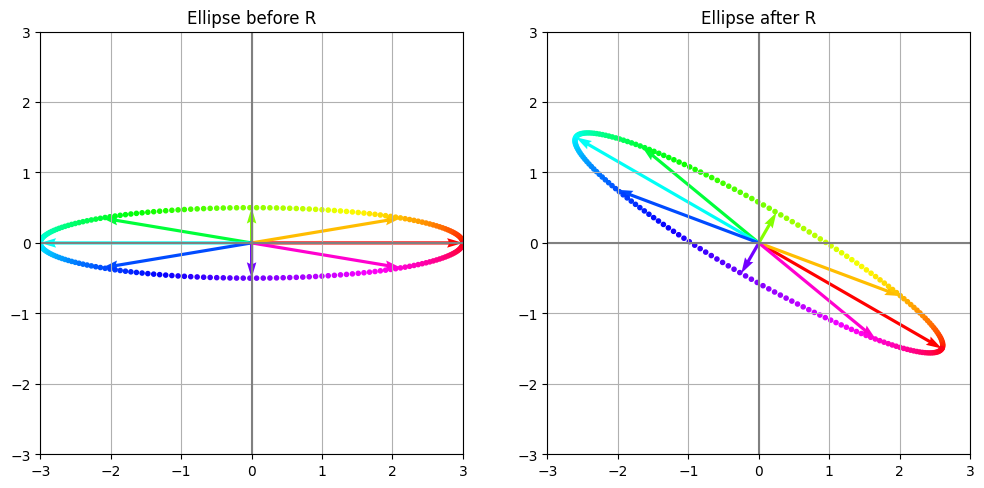

In [14]:
# Stretch the unit circle of arrows into an ellipse and then R applied to it.
# Display the two next to each other. 

fig,ax = LADS2DSquare(2,xlow=-3.,xhigh=3.)

M = np.diag([3.,0.5])
R = RotationMatrix2D(-np.pi/6.)
# By calling "LADS2DSquare" with the argument 2, we create an array of two axes, ax[0] and ax[1]. 
# We put the "before" picture on ax[0] and the "after" picture on ax[1].

EllipseArrows = M @ List_of_Arrows_on_Circle
Ellipse = M@UnitCirclePoints

ax[0].set_title('Ellipse before R')
ax[0].LADS2DDrawVectorList(EllipseArrows,columns=True)
ax[0].scatter(*Ellipse,marker=".",c=colors,cmap=cm.hsv)

TransformedArrows = R @ EllipseArrows
TransformedEllipse = R @ Ellipse

ax[1].set_title('Ellipse after R')
ax[1].LADS2DDrawVectorList(TransformedArrows,columns=True)
ax[1].scatter(*TransformedEllipse,marker=".",c=colors,cmap=cm.hsv)



#### Do it: 
Modify the code above to produce two plots: one is an ellipse stretched by 2 along the $x$-axis and $0.3$ along the $y$-axis. The other second plot is that ellipse, rotated counterclockwise by 90 degrees (which is $\pi/2$ radians).

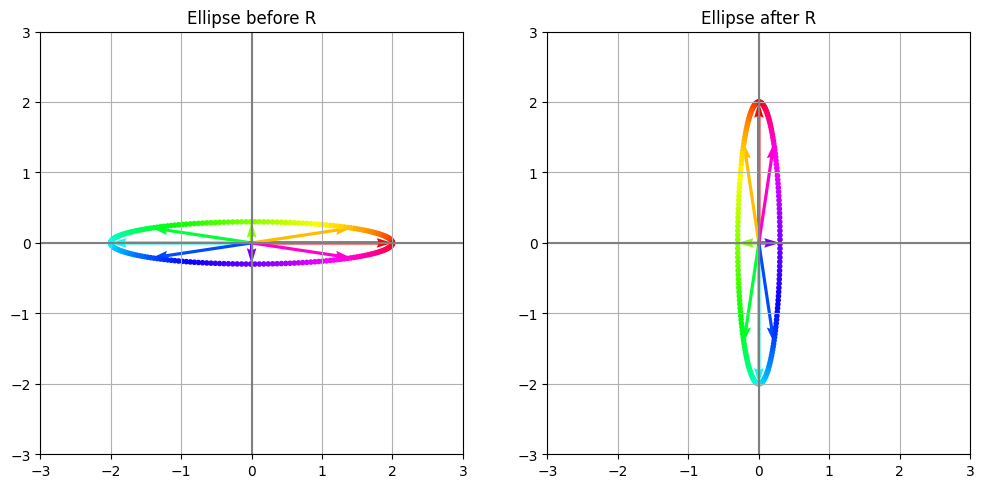

In [15]:
fig,ax = LADS2DSquare(2,xlow=-3.,xhigh=3.)

M = np.diag([2.,0.3])
R = RotationMatrix2D(np.pi/2.)
# By calling "LADS2DSquare" with the argument 2, we create an array of two axes, ax[0] and ax[1]. 
# We put the "before" picture on ax[0] and the "after" picture on ax[1].

EllipseArrows = M @ List_of_Arrows_on_Circle
Ellipse = M@UnitCirclePoints

ax[0].set_title('Ellipse before R')
ax[0].LADS2DDrawVectorList(EllipseArrows,columns=True)
ax[0].scatter(*Ellipse,marker=".",c=colors,cmap=cm.hsv)

TransformedArrows = R @ EllipseArrows
TransformedEllipse = R @ Ellipse

ax[1].set_title('Ellipse after R')
ax[1].LADS2DDrawVectorList(TransformedArrows,columns=True)
ax[1].scatter(*TransformedEllipse,marker=".",c=colors,cmap=cm.hsv)

In the last two drawings, we first stretched the unit circle into an ellipse, and then we rotated the ellipse. Next week we'll learn about matrix multiplication, which will enable us to build a matrix that stretches and rotates in one step.